# Anomaly Detection on the 40 MHz dataset

Baseline from: https://arxiv.org/pdf/2006.02516.pdf
Idea and datasets extracted from https://arxiv.org/pdf/2108.03986

- 56 inputs (18 objects (4 mu, 4 el, 10 jets) x pt, eta, phi + pt and phi of MET)

- The rest is just kept standard for now.
- Embedding: TrigonometricEmbedding (p=2)
- Combined loss: $\mathcal{L} = \frac{1}{N}\sum_{i=1}^{N} \left( \log \left\| P \Phi({X_i}) \right\|_2^2 - 1 \right)^2 + \alpha \cdot \mathrm{ReLU}\left(\log(\|P\|_F^2)\right)$

**Imports**

In [3]:
import os
os.environ["KMP_WARNINGS"] = "0"
os.environ["CUDA_VISIBLE_DEVICES"] = "0"
import jax
import jax.numpy as jnp
import numpy as np
import optax
from sklearn.metrics import auc
import tensorflow as tf
from tensorflow.keras.datasets import mnist
from jax.nn.initializers import *
import matplotlib.pyplot as plt
import h5py

from tn4ml.initializers import *
from tn4ml.models.smpo import *
from tn4ml.models.model import *
from tn4ml.embeddings import *
from tn4ml.metrics import *
from tn4ml.util import *
from tn4ml.eval import *

2025-04-24 08:44:18.920842: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1745509458.933339   76312 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1745509458.937591   76312 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1745509458.947980   76312 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1745509458.947990   76312 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1745509458.947992   76312 computation_placer.cc:177] computation placer alr

In [5]:
jax.config.update("jax_enable_x64", True)

**Load 40 MHz dataset**

In [30]:
from hep_data import *
inputPath = "/global/cfs/cdirs/m2616/sagar/QiML/"
h5_file = h5py.File(inputPath+"background_for_training.h5", 'r')

dataset = create_tf_dataset(h5_file, 'Particles', batch_size=64)

In [31]:
# Apply the transformation using a lambda function with transposed structure
structured_dataset = dataset.map(lambda batch: {
    'MET': {
        'pt': tf.transpose(batch[:, 0:1, 0], [1, 0]),    # Shape: (1, batch_size)
        # 'eta': tf.transpose(batch[:, 0:1, 1], [1, 0]),   # Shape: (1, batch_size)
        'phi': tf.transpose(batch[:, 0:1, 2], [1, 0]),   # Shape: (1, batch_size)
    },
    'Ele': {
        'pt': tf.transpose(batch[:, 1:5, 0], [1, 0]),    # Shape: (4, batch_size)
        'eta': tf.transpose(batch[:, 1:5, 1], [1, 0]),   # Shape: (4, batch_size)
        'phi': tf.transpose(batch[:, 1:5, 2], [1, 0]),   # Shape: (4, batch_size)
    },
    'Mu': {
        'pt': tf.transpose(batch[:, 5:9, 0], [1, 0]),    # Shape: (4, batch_size)
        'eta': tf.transpose(batch[:, 5:9, 1], [1, 0]),   # Shape: (4, batch_size)
        'phi': tf.transpose(batch[:, 5:9, 2], [1, 0]),   # Shape: (4, batch_size)
    },
    'Jet': {
        'pt': tf.transpose(batch[:, 9:19, 0], [1, 0]),   # Shape: (10, batch_size)
        'eta': tf.transpose(batch[:, 9:19, 1], [1, 0]),  # Shape: (10, batch_size)
        'phi': tf.transpose(batch[:, 9:19, 2], [1, 0]),  # Shape: (10, batch_size)
    }
})

In [32]:
# Test the resulting dataset
for batch_dict in structured_dataset.take(1):
    print("MET pt shape:", batch_dict['MET']['pt'].shape)
    print("Ele eta shape:", batch_dict['Ele']['eta'].shape)
    print("Mu phi shape:", batch_dict['Mu']['phi'].shape)
    print("Jet pt shape:", batch_dict['Jet']['pt'].shape)
    
    # Print a sample from each category
    print("\nLeading MET pt:")
    print(batch_dict['MET']['pt'][0])  # First MET across batch
    
    print("\nLeading Electron pt:")
    print(batch_dict['Ele']['pt'][0])  # First electron eta across batch
    
    print("\nLeading Muon phi:")
    print(batch_dict['Mu']['phi'][0])  # First muon phi across batch
    
    print("\nLeading Jet pt:")
    print(batch_dict['Jet']['pt'][0])  # First jet pt across batch

MET pt shape: (1, 64)
Ele eta shape: (4, 64)
Mu phi shape: (4, 64)
Jet pt shape: (10, 64)

Leading MET pt:
tf.Tensor(
[30.32235718 26.88205338 39.45802307 21.34718513 44.2074852  35.53755951
 11.94241333 18.12940788 28.70663452 53.35020447 25.71606064 22.22262192
 22.39255142 52.67155838 55.13599014 47.97408295 62.80233002 49.37962723
 16.86823082 14.95151234 42.10663605 23.82073212 36.57559967 34.61443329
 47.39333344 34.35577393 47.46212387 44.05821991 67.685112   52.71432877
 62.68491745 51.02716446 31.37352943 16.96141434 12.59181213 36.13666534
 30.50669098  3.53161097 18.52491188 34.79120255 42.78905106 33.28141403
 37.26205444 42.19327545 58.2864151  20.07905579 52.23825836 41.95663452
 17.74259186 46.29518509 24.62340164 15.21833324 24.34587669 40.30252075
 39.49405289 13.09393024 21.84231377 67.23051453 31.90024376 58.9582901
 28.08685684 50.61374664  2.44113827 44.19660568], shape=(64,), dtype=float64)

Leading Electron eta:
tf.Tensor(
[ 0.         -0.0620594   0.         -2.

In [ ]:
**Optional block to create plots of all features**

In [44]:
# Create output directory
output_dir = "feature_plots"
os.makedirs(output_dir, exist_ok=True)

# Function to collect data from multiple batches
def collect_data(dataset, max_batches):
    data = {
        'MET': {'pt': [], 'phi': []},
        'Ele': {'pt': [], 'eta': [], 'phi': []},
        'Mu': {'pt': [], 'eta': [], 'phi': []},
        'Jet': {'pt': [], 'eta': [], 'phi': []}
    }
    
    for i, batch_dict in enumerate(dataset):
        if i >= max_batches:
            break
            
        # MET
        data['MET']['pt'].append(batch_dict['MET']['pt'][0].numpy())
        data['MET']['phi'].append(batch_dict['MET']['phi'][0].numpy())
        
        # Electrons
        for j in range(4):
            data['Ele']['pt'].append(batch_dict['Ele']['pt'][j].numpy())
            data['Ele']['eta'].append(batch_dict['Ele']['eta'][j].numpy())
            data['Ele']['phi'].append(batch_dict['Ele']['phi'][j].numpy())
        
        # Muons
        for j in range(4):
            data['Mu']['pt'].append(batch_dict['Mu']['pt'][j].numpy())
            data['Mu']['eta'].append(batch_dict['Mu']['eta'][j].numpy())
            data['Mu']['phi'].append(batch_dict['Mu']['phi'][j].numpy())
        
        # Jets
        for j in range(10):
            data['Jet']['pt'].append(batch_dict['Jet']['pt'][j].numpy())
            data['Jet']['eta'].append(batch_dict['Jet']['eta'][j].numpy())
            data['Jet']['phi'].append(batch_dict['Jet']['phi'][j].numpy())
    
    # Concatenate all batches
    for particle in data:
        for feature in data[particle]:
            data[particle][feature] = np.concatenate(data[particle][feature])
    
    return data

# Collect data from half the dataset
total_batches = sum(1 for _ in structured_dataset)
data = collect_data(structured_dataset, max_batches=total_batches//2)

<>:56: SyntaxWarning: invalid escape sequence '\e'
<>:57: SyntaxWarning: invalid escape sequence '\p'
<>:56: SyntaxWarning: invalid escape sequence '\e'
<>:57: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_76312/430807167.py:56: SyntaxWarning: invalid escape sequence '\e'
  'eta': '$\eta$ [no units]',
/tmp/ipykernel_76312/430807167.py:57: SyntaxWarning: invalid escape sequence '\p'
  'phi': '$\phi$ [rad]'
/tmp/ipykernel_76312/430807167.py:56: SyntaxWarning: invalid escape sequence '\e'
  'eta': '$\eta$ [no units]',
/tmp/ipykernel_76312/430807167.py:57: SyntaxWarning: invalid escape sequence '\p'
  'phi': '$\phi$ [rad]'


NameError: name 'plot' is not defined

<Figure size 1000x600 with 0 Axes>

In [50]:
# Plot styling
plt.style.use('seaborn-v0_8-darkgrid')
colors = {'MET': 'crimson', 'Ele': 'royalblue', 'Mu': 'forestgreen', 'Jet': 'darkorange'}
labels = {
    'pt': 'p$_T$ [GeV]', 
    'eta': '$\eta$', 
    'phi': '$\phi$ [rad]'
}

# Create plots for each feature
for particle in data:
    for feature in data[particle]:
        values = data[particle][feature]
        
        plt.figure(figsize=(10, 6))
        plt.yscale('log')
        plt.ylim(1e-3, 10)  # Set y-axis range

        if feature == 'pt':
            counts, bins = np.histogram(values, bins=100, range=(0, 100))
            counts = counts / counts.sum()  # Normalize so sum of all bins = 1
            plt.bar(bins[:-1], counts, width=np.diff(bins), color=colors[particle], alpha=0.7)
            plt.xticks(np.arange(0, 101, 10))
        elif feature == 'eta':
            counts, bins = np.histogram(values, bins=101, range=(-5, 5))
            counts = counts / counts.sum()  # Normalize so sum of all bins = 1
            plt.bar(bins[:-1], counts, width=np.diff(bins), color=colors[particle], alpha=0.7)
            plt.xticks(np.arange(-5, 5.1, 1))
        elif feature == 'phi':
            counts, bins = np.histogram(values, bins=101, range=(-np.pi, np.pi))
            counts = counts / counts.sum()  # Normalize so sum of all bins = 1
            plt.bar(bins[:-1], counts, width=np.diff(bins), color=colors[particle], alpha=0.7)
            plt.xticks(np.linspace(-np.pi, np.pi, 13), ["-π", "", "-2π/3", "", "-π/3", "", "0", "", "π/3", "", "2π/3", "", "π"])

        
        plt.title(f'{particle} {feature} Distribution', fontsize=16)
        plt.xlabel(labels[feature], fontsize=14)
        plt.ylabel('Events', fontsize=14)
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        
        # Save figure
        filename = f"{output_dir}/{particle}_{feature}.png"
        plt.savefig(filename, dpi=150)
        plt.close()
        
        print(f"Saved plot to {filename}")

print(f"\nAll plots saved to '{output_dir}' directory")

<>:6: SyntaxWarning: invalid escape sequence '\e'
<>:7: SyntaxWarning: invalid escape sequence '\p'
<>:6: SyntaxWarning: invalid escape sequence '\e'
<>:7: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_76312/4138130867.py:6: SyntaxWarning: invalid escape sequence '\e'
  'eta': '$\eta$',
/tmp/ipykernel_76312/4138130867.py:7: SyntaxWarning: invalid escape sequence '\p'
  'phi': '$\phi$ [rad]'


Saved plot to feature_plots/MET_pt.png
Saved plot to feature_plots/MET_phi.png
Saved plot to feature_plots/Ele_pt.png
Saved plot to feature_plots/Ele_eta.png
Saved plot to feature_plots/Ele_phi.png
Saved plot to feature_plots/Mu_pt.png
Saved plot to feature_plots/Mu_eta.png
Saved plot to feature_plots/Mu_phi.png
Saved plot to feature_plots/Jet_pt.png
Saved plot to feature_plots/Jet_eta.png
Saved plot to feature_plots/Jet_phi.png

All plots saved to 'feature_plots' directory


**Load MNIST dataset**

In [19]:
train, test = mnist.load_data()
data = {"X": dict(train=train[0], test=test[0]), "y": dict(train=train[1], test=test[1])}

In [4]:
normal_class = 0

In [5]:
X = {
"normal": data["X"]["train"][data["y"]["train"] == normal_class]/255.0,
"anomaly": data["X"]["train"][data["y"]["train"] != normal_class]/255.0,
}

In [6]:
X_test = {
"normal": data["X"]["test"][data["y"]["test"] == normal_class]/255.0,
"anomaly": data["X"]["test"][data["y"]["test"] != normal_class]/255.0,
}

In [7]:
# Function to resize images to 14x14
def resize_images(images):
    resized_images = tf.image.resize(images, [14, 14], method=tf.image.ResizeMethod.AREA)
    return resized_images.numpy()

In [8]:
X_resized = {
    "normal": resize_images(np.expand_dims(X["normal"], axis=-1)),
    "anomaly": resize_images(np.expand_dims(X["anomaly"], axis=-1)),
}

X_test_resized = {
    "normal": resize_images(np.expand_dims(X_test["normal"], axis=-1)),
    "anomaly": resize_images(np.expand_dims(X_test["anomaly"], axis=-1)),
}

I0000 00:00:1745502804.560180   44392 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 38366 MB memory:  -> device: 0, name: NVIDIA A100-SXM4-40GB, pci bus id: 0000:03:00.0, compute capability: 8.0


### Rearrange pixels in zig-zag order
- (from https://arxiv.org/pdf/1605.05775.pdf)

<img src="images/zig-zag.png" alt="MPS Params" width="150" height="150">

In [13]:
def zigzag_order(data):
    data = np.squeeze(data)
    data_zigzag = []
    for x in data:
        image = []
        for i in x:
            image.extend(i)
        data_zigzag.append(image)
    return np.asarray(data_zigzag)

In [14]:
zigzag = True

In [15]:
if zigzag:
    train_normal = zigzag_order(X_resized["normal"])
    test_normal = zigzag_order(X_test_resized["normal"])

    train_anomaly = zigzag_order(X_resized["anomaly"])
    test_anomaly = zigzag_order(X_test_resized["anomaly"])
else:
    train_normal = X_resized['normal'].reshape(-1, X_resized['normal'].shape[1]*X_resized['normal'].shape[2])
    test_normal = X_test_resized['normal'].reshape(-1, X_test_resized['normal'].shape[1]*X_test_resized['normal'].shape[2])

    train_anomaly = X_resized['anomaly'].reshape(-1, X_resized['anomaly'].shape[1]*X_resized['anomaly'].shape[2])
    test_anomaly = X_test_resized['anomaly'].reshape(-1, X_test_resized['anomaly'].shape[1]*X_test_resized['anomaly'].shape[2])

**Training setup** &nbsp;
- Stochastic Gradient Descent

In [16]:
# define model parameters
L = 196
initializer = gramschmidt('normal', 1e-1)
key = jax.random.key(42)
shape_method = 'noteven'
bond_dim = 10
phys_dim = (2,2)
spacing = 8
add_identity = True
boundary='obc'

In [17]:
model = SMPO_initialize(L=L,
                        initializer=initializer,
                        key=key,
                        shape_method=shape_method,
                        spacing=spacing,
                        bond_dim=bond_dim,
                        phys_dim=phys_dim,
                        cyclic=False,
                        compress=True,
                        add_identity=add_identity,
                        boundary=boundary)

In [18]:
alpha = 0.4
def loss_combined(*args, **kwargs):
    error = LogQuadNorm
    reg = LogReLUFrobNorm
    return CombinedLoss(*args, **kwargs, error=error, reg=lambda P: alpha*reg(P))

In [19]:
# define training parameters
epochs = 100
batch_size = 128
optimizer = optax.adam
strategy = 'global'
loss = loss_combined
train_type = TrainingType.UNSUPERVISED
embedding = TrigonometricEmbedding()
learning_rate = 1e-4
earlystop = EarlyStopping(min_delta=0, patience=5, monitor='loss', mode='min')

model.configure(optimizer=optimizer, strategy=strategy, loss=loss, train_type=train_type, learning_rate=learning_rate)

In [20]:
history = model.train(train_normal,
            epochs=epochs,
            batch_size=batch_size,
            embedding = embedding,
            normalize=True,
            earlystop=earlystop,
            cache=True, # compiling loss function to use it multiple times
            dtype=jnp.float64)

epoch:  19%|█▉         19/100 , loss=6260.3685

Waiting for 1 epochs.


epoch:  20%|██         20/100 , loss=6267.6760

Waiting for 2 epochs.


epoch:  21%|██         21/100 , loss=6308.7788

...

epoch:  22%|██▏        22/100 , loss=6375.5519

Waiting for 4 epochs.


epoch:  23%|██▎        23/100 , loss=6463.0778

Training stopped by EarlyStopping on epoch: 18


epoch:  24%|██▍        24/100 , loss=6571.7614


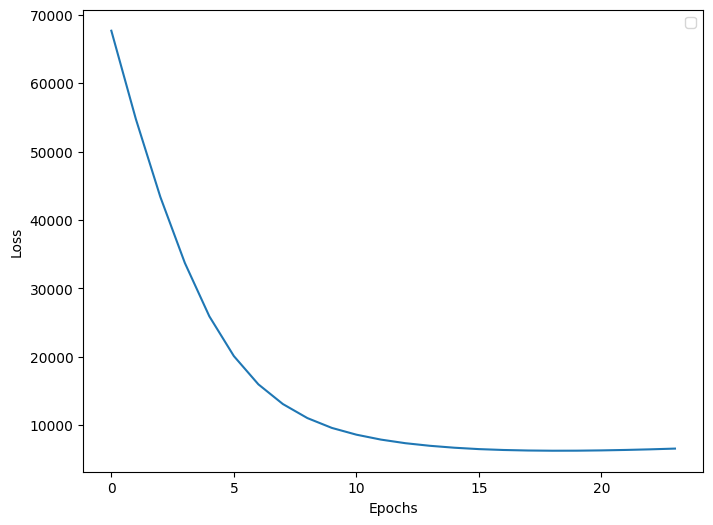

In [21]:
plot_loss(history, validation=False, figsize=(8, 6))

**Evaluate**

In [22]:
indices = list(range(len(test_anomaly)))
np.random.shuffle(indices)

indices = indices[:len(test_normal)]
test_anomaly = np.take(test_anomaly, indices, axis=0)

In [23]:
loss = LogQuadNorm

anomaly_score = model.evaluate(test_anomaly, evaluate_type=train_type, return_list=True, dtype=jnp.float64, batch_size=128, embedding=embedding, metric = loss)
normal_score = model.evaluate(test_normal, evaluate_type=train_type, return_list=True, dtype=jnp.float64, batch_size=128, embedding=embedding, metric = loss)

**Plot anomaly scores and ROC curve**

In [24]:
fpr, tpr = get_roc_curve_data(normal_score, anomaly_score, anomaly_det=True)
auc_value = auc(fpr, tpr)

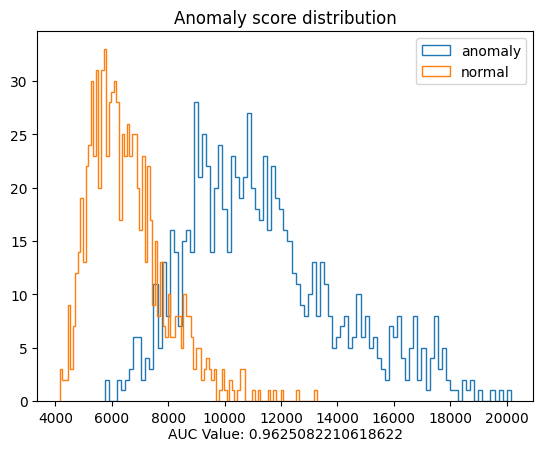

In [25]:
plt.figure()
plt.hist(anomaly_score, bins=100, histtype='step', label='anomaly')
plt.hist(normal_score, bins=100, histtype='step', label='normal')
plt.title('Anomaly score distribution')
plt.legend()
plt.text(0.5, -0.1, f'AUC Value: {auc_value}', ha='center', transform=plt.gca().transAxes)
plt.legend()
plt.show()

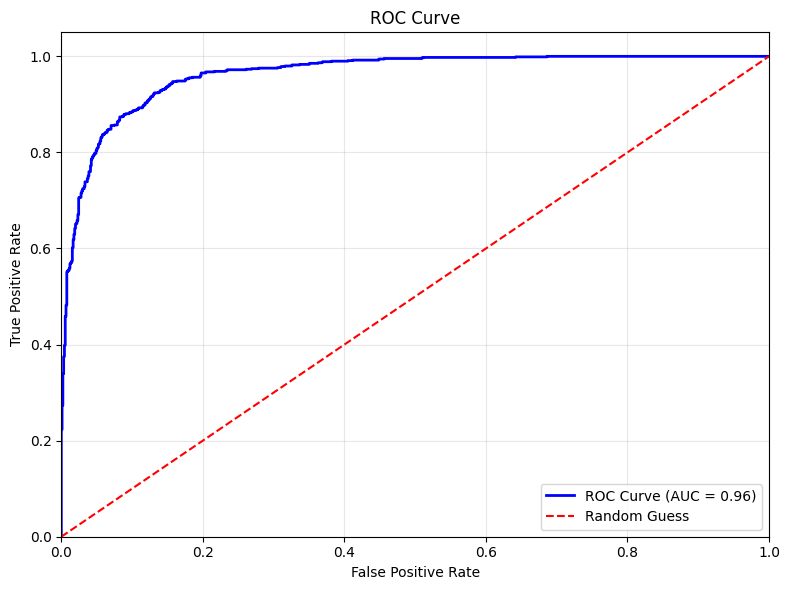

In [26]:
# Plot ROC curve
plot_ROC_curve_from_data(fpr, tpr)